Chọn hành động trong REINFORCE
Viết hàm select_action cho REINFORCE, hàm này sẽ được tác tử REINFORCE của bạn dùng để chọn hành động ở mỗi bước.

Trong DQN, lượt truyền xuôi của mạng trả về các giá trị Q; trong REINFORCE, nó trả về xác suất hành động, từ đó có thể lấy mẫu trực tiếp một hành động.

Một policy network và một state đã được nạp sẵn trong môi trường của bạn.

torch.distributions.Categorical đã được import với tên Categorical.

Hướng dẫn
100 XP
Lấy xác suất hành động dưới dạng một tensor của torch.
Tạo đối tượng torch Distribution tương ứng với các xác suất hành động.
Lấy mẫu một hành động từ phân phối đó.

In [ ]:
def select_action(policy_network, state):
  # Obtain the action probabilities
  action_probs = ____
  print('Action probabilities:', action_probs)
  # Instantiate the action distribution
  action_dist = Categorical(____)
  # Sample an action from the distribution
  action = ____
  log_prob = action_dist.log_prob(action)
  return action.item(), log_prob.reshape(1)

state = torch.rand(8)
action, log_prob = select_action(policy_network, state)
print('Sampled action index:', action)
print(f'Log probability of sampled action: {log_prob.item():.2f}')

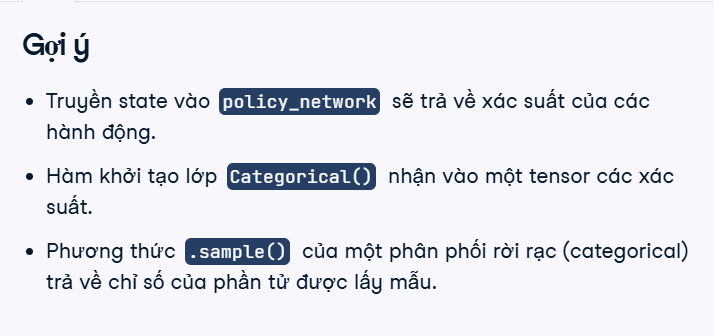

In [ ]:
"""
def select_action(policy_network, state):
  # Obtain the action probabilities
  action_probs = policy_network(state)
  print('Action probabilities:', action_probs)
  # Instantiate the action distribution
  action_dist = Categorical(action_probs)
  # Sample an action from the distribution
  action = action_dist.sample()
  log_prob = action_dist.log_prob(action)
  return action.item(), log_prob.reshape(1)

state = torch.rand(8)
action, log_prob = select_action(policy_network, state)
print('Sampled action index:', action)
print(f'Log probability of sampled action: {log_prob.item():.2f}')

"""

Huấn luyện thuật toán REINFORCE
Bạn đã sẵn sàng huấn luyện Lunar Lander bằng REINFORCE! Việc bạn cần làm là triển khai vòng lặp huấn luyện REINFORCE, bao gồm cả bước tính hàm mất mát REINFORCE.

Vì các bước tính mất mát trải dài ở cả vòng lặp trong và ngoài, lần này bạn sẽ không dùng hàm calculate_loss().

Khi episode kết thúc, bạn có thể dùng cả hai đại lượng đó để tính mất mát.

Tham khảo, đây là biểu thức của hàm mất mát REINFORCE:

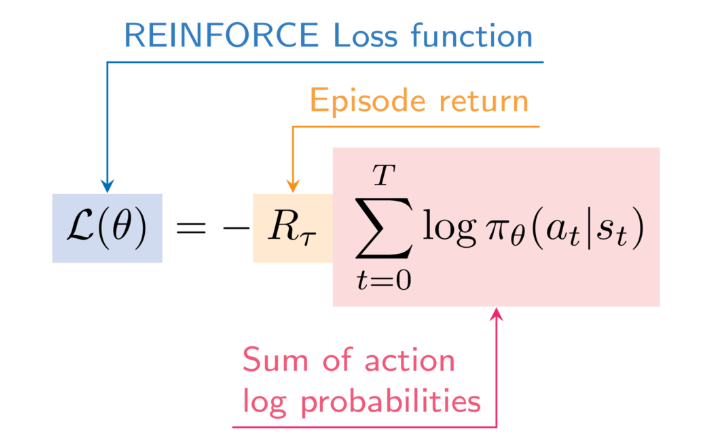

Bạn sẽ tiếp tục dùng hàm describe_episode() để in ra tiến độ của tác tử sau mỗi episode.

Hướng dẫn
100 XP
Thêm log xác suất của hành động đã chọn vào danh sách log xác suất của episode.
Cộng dồn tổng phần thưởng của episode với phần thưởng đã chiết khấu tại bước hiện tại.
Tính hàm mất mát REINFORCE cho episode

In [1]:
for episode in range(50):
    state, info = env.reset()
    done = False
    episode_reward = 0
    step = 0
    episode_log_probs = torch.tensor([])
    R = 0
    while not done:
        step += 1
        action, log_prob = select_action(policy_network, state)                
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode_reward += reward
        # Append to the episode action log probabilities
        episode_log_probs = torch.cat((____, ____))
        # Increment the episode return
        R += (____ ** step) * ____
        state = next_state
    # Calculate the episode loss
    loss = ____ * ____.sum()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    describe_episode(episode, reward, episode_reward, step)

NameError: name 'env' is not defined

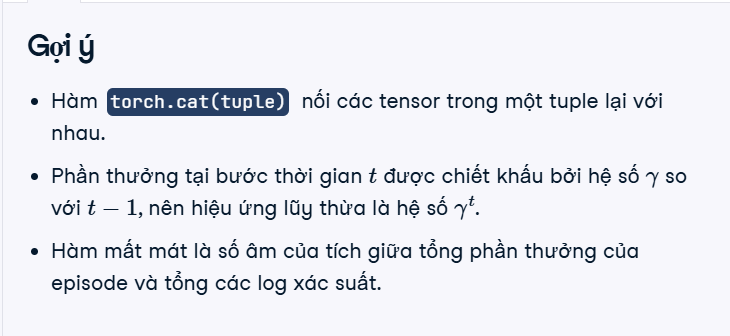

In [ ]:
"""
for episode in range(50):
    state, info = env.reset()
    done = False
    episode_reward = 0
    step = 0
    episode_log_probs = torch.tensor([])
    R = 0
    while not done:
        step += 1
        action, log_prob = select_action(policy_network, state)                
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode_reward += reward
        # Append to the episode action log probabilities
        episode_log_probs = torch.cat((episode_log_probs, log_prob))
        # Increment the episode return
        R += (gamma ** step) * reward
        state = next_state
    # Calculate the episode loss
    loss = - R * episode_log_probs.sum()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    describe_episode(episode, reward, episode_reward, step)
    
    """